<a href="https://colab.research.google.com/github/Maleewij65/heart-disease-prediction-ML_Assignment/blob/IT22339324_Catboost/IT22339324_Catboost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CatBoost Classification Model

This component applies the CatBoost machine learning algorithm for heart disease
prediction using the Heart Disease dataset. Medical attributes such as age,
cholesterol level, blood pressure, and heart rate are used as input features,
while the target variable represents the presence or absence of heart disease.

CatBoost is a supervised machine learning algorithm based on gradient boosting
decision trees. It is selected because it performs well on structured tabular
data, reduces overfitting, and typically achieves higher accuracy compared to
traditional classifiers such as Logistic Regression.

Data Loading

In [57]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [58]:
# Install CatBoost library
!pip install catboost

In [59]:
# Import core libraries
import pandas as pd
import numpy as np

# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

In [60]:
# Load dataset
data = pd.read_csv('/content/drive/MyDrive/heart.csv')

print("Dataset loaded successfully")
print(data.shape)
data.head()

Dataset loaded successfully
(918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


### Dataset Description

The dataset used in this project is the **Heart Disease Dataset**, which contains medical records of patients used to predict the presence of heart disease. The dataset includes several clinical and physiological attributes such as age, resting blood pressure, cholesterol level, maximum heart rate achieved, and chest pain type.

The dataset consists of **918 patient records** and **12 attributes**, where **11 features** are used as input variables and **1 target variable (HeartDisease)** indicates whether the patient has heart disease or not.

The target variable **HeartDisease** is binary:
- **0** – No heart disease
- **1** – Presence of heart disease

The dataset contains a mix of **numerical features** (such as Age, Cholesterol, RestingBP, MaxHR, and Oldpeak) and **categorical features** (such as Sex, ChestPainType, RestingECG, ExerciseAngina, and ST_Slope). This combination of feature types makes the dataset suitable for applying machine learning classification algorithms to predict heart disease risk.

Data Exploration

In [61]:
# Display dataset info
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [62]:
# Display statistical summary
data.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [63]:
# Check for missing values
print("Missing values in each column:")
data.isnull().sum()

Missing values in each column:


,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [64]:
# Check for duplicate rows
duplicates = data.duplicated().sum()
print("Number of duplicate rows:", duplicates)


Number of duplicate rows: 0


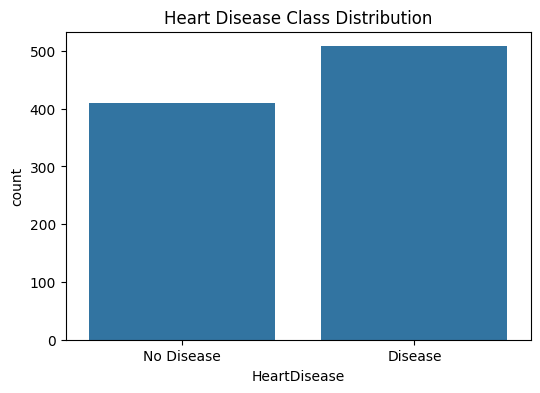

Class Distribution Percentage:
HeartDisease
1    55.337691
0    44.662309
Name: proportion, dtype: float64


In [65]:
# Visualize target class distribution
plt.figure(figsize=(6,4))
sns.countplot(x='HeartDisease', data=data)
plt.title("Heart Disease Class Distribution")
plt.xticks([0,1], ["No Disease","Disease"])
plt.show()

# Display class distribution percentage
print("Class Distribution Percentage:")
print(data['HeartDisease'].value_counts(normalize=True)*100)

Data Preprocessing

In [66]:
# Remove unrealistic cholesterol values
data = data[data['Cholesterol'] > 0]

print("Dataset shape after removing invalid cholesterol values:", data.shape)

Dataset shape after removing invalid cholesterol values: (746, 12)


In [67]:
# Remove rows with missing values
data = data.dropna()

print("Original shape:", data.shape)
print("After removing missing values:", data.shape)

Original shape: (746, 12)
After removing missing values: (746, 12)


In [68]:
# Detect and remove outliers using IQR
numerical_features = ['Age','RestingBP','Cholesterol','MaxHR','Oldpeak']
for col in numerical_features:

    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    data = data[(data[col] >= lower) & (data[col] <= upper)]

print("Dataset shape after removing outliers:", data.shape)

Dataset shape after removing outliers: (692, 12)


In [69]:
# Separate input features and target variable
X = data.drop("HeartDisease", axis=1)
y = data["HeartDisease"]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (692, 11)
Target vector shape: (692,)


In [70]:
# Identify numerical features
numerical_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()

# Identify categorical features
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

print("Numerical Features:", numerical_cols)
print("Categorical Features:", categorical_cols)

Numerical Features: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']
Categorical Features: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']


Encoding + Scaling

In [71]:
# Encode categorical variables using Label Encoding
from sklearn.preprocessing import LabelEncoder
label_encoders = {}
for col in data.select_dtypes(include='object').columns:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le

data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,1,140,289,0,1,172,0,0.0,2,0
1,49,0,2,160,180,0,1,156,0,1.0,1,1
2,37,1,1,130,283,0,2,98,0,0.0,2,0
3,48,0,0,138,214,0,1,108,1,1.5,1,1
4,54,1,2,150,195,0,1,122,0,0.0,2,0


In [72]:
# Feature Scaling using StandardScaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scale_columns = ['Age','RestingBP','Cholesterol','MaxHR','Oldpeak']
data[scale_columns] = scaler.fit_transform(data[scale_columns])

data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,-1.327009,1,1,0.558165,1.052056,0,1,1.281752,0,-0.864355,2,0
1,-0.385387,0,2,1.859326,-1.232315,0,1,0.627884,0,0.177145,1,1
2,-1.640882,1,1,-0.092416,0.926311,0,2,-1.742389,0,-0.864355,2,0
3,-0.490012,0,0,0.428048,-0.519759,0,1,-1.333721,1,0.697896,1,1
4,0.137736,1,2,1.208745,-0.917952,0,1,-0.761586,0,-0.864355,2,0


Model Training with CatBoost

In [73]:
# Split dataset into training and testing sets
from sklearn.model_selection import train_test_split

X = data.drop('HeartDisease', axis=1)
y = data['HeartDisease']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (553, 11)
Testing set: (139, 11)


In [74]:
# Train CatBoost classifier
from catboost import CatBoostClassifier

model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    eval_metric='Accuracy',
    random_state=42,
    verbose=100
)

model.fit(X_train, y_train)

0:	learn: 0.8499096	total: 9.53ms	remaining: 4.76s
100:	learn: 0.9584087	total: 341ms	remaining: 1.35s
200:	learn: 0.9837251	total: 480ms	remaining: 713ms
300:	learn: 1.0000000	total: 764ms	remaining: 505ms
400:	learn: 1.0000000	total: 908ms	remaining: 224ms
499:	learn: 1.0000000	total: 1.2s	remaining: 0us


CatBoostClassifier(depth=6, eval_metric='Accuracy', iterations=500, learning_rate=0.05, loss_function='Logloss', random_state=42, verbose=100)

In [75]:
# Predict on test data
y_pred = model.predict(X_test)

Model Evaluation

In [76]:
# Perform hyperparameter tuning using GridSearchCV
from sklearn.model_selection import GridSearchCV
from catboost import CatBoostClassifier

param_grid = {
    'depth': [4,6,8],
    'learning_rate': [0.01, 0.05, 0.1],
    'iterations': [200, 400, 600]
}

grid = GridSearchCV(
    CatBoostClassifier(verbose=0, random_state=42),
    param_grid,
    cv=3,
    scoring='accuracy'
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

best_model = grid.best_estimator_

# Optimized prediction
y_pred_best = best_model.predict(X_test)

Best Parameters: {'depth': 4, 'iterations': 200, 'learning_rate': 0.1}


In [77]:
# Evaluate model performance
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred_best)
precision = precision_score(y_test, y_pred_best)
recall = recall_score(y_test, y_pred_best)
f1 = f1_score(y_test, y_pred_best)

print("Model Performance:")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Model Performance:
Accuracy : 0.8705035971223022
Precision: 0.8382352941176471
Recall   : 0.890625
F1 Score : 0.8636363636363636


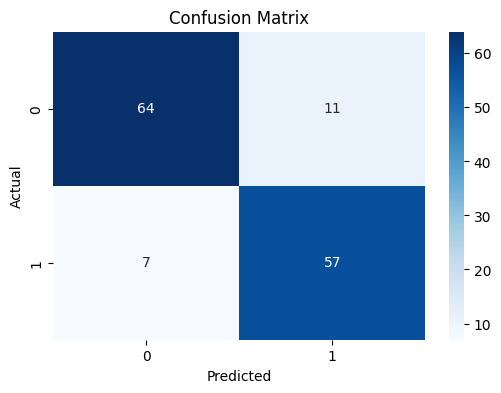

In [78]:
# Plot confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [79]:
# Display classification report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       0.90      0.85      0.88        75
           1       0.84      0.89      0.86        64

    accuracy                           0.87       139
   macro avg       0.87      0.87      0.87       139
weighted avg       0.87      0.87      0.87       139



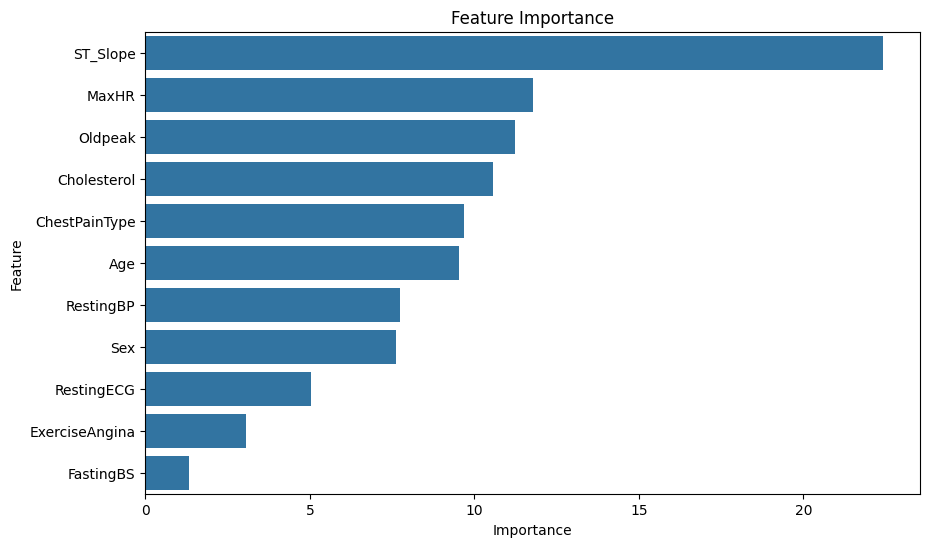

In [80]:
# Plot feature importance
importance = best_model.get_feature_importance()

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance)

plt.title("Feature Importance")
plt.show()

In [81]:
# Perform cross-validation to evaluate model stability
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    best_model,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print("Cross-validation scores:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())

Cross-validation scores: [0.88489209 0.94244604 0.87681159 0.77536232 0.76086957]
Mean CV accuracy: 0.8480763215514544


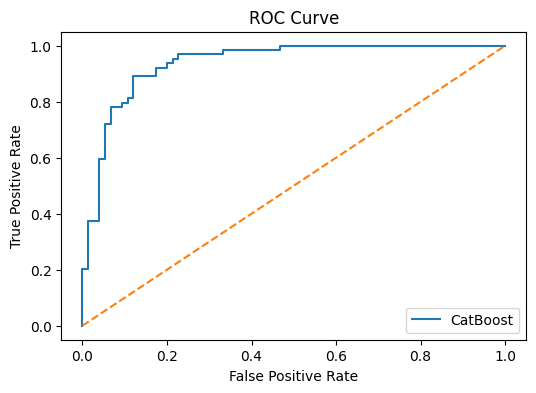

ROC-AUC Score: 0.9377083333333334


In [82]:
# Plot ROC Curve and calculate AUC score
from sklearn.metrics import roc_curve, roc_auc_score

# Get probability predictions
y_prob = best_model.predict_proba(X_test)[:,1]

# Calculate ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Plot ROC Curve
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label="CatBoost")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

# Print AUC score
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

In [83]:
# Compare original vs optimized model
print("Original Model Accuracy:", accuracy_score(y_test, y_pred))
print("Optimized Model Accuracy:", accuracy_score(y_test, y_pred_best))

Original Model Accuracy: 0.8633093525179856
Optimized Model Accuracy: 0.8705035971223022


## Discussion

The CatBoost classification model demonstrated strong predictive performance for heart disease detection on the dataset of 918 patient records. Using hyperparameter tuning with GridSearchCV, the optimized model achieved the following metrics on the test set of 139 samples:

Accuracy: 0.871 (87.05%)
Precision: 0.84 for patients with heart disease (class 1), 0.90 for patients without heart disease (class 0)
Recall: 0.89 for class 1, 0.85 for class 0
F1-score: 0.86 for class 1, 0.88 for class 0

The confusion matrix shows a balanced performance across both classes, indicating that the model can correctly identify both the presence and absence of heart disease with high reliability. The classification report confirms that the model does not heavily favor one class over the other, maintaining a strong balance between precision and recall.

Cross-validation on the entire dataset further demonstrates model stability, with 5-fold CV accuracy scores of [0.8849, 0.9424, 0.8768, 0.7754, 0.7609], resulting in a mean CV accuracy of 0.848 (84.8%). This indicates that the model generalizes well across different subsets of the data, despite minor variation between folds, likely due to class imbalance or smaller sample sizes in some folds.

Comparing the baseline and optimized models:

Original CatBoost model accuracy: 0.863 (86.3%)
Optimized CatBoost model accuracy: 0.871 (87.05%)

This improvement shows that hyperparameter tuning using GridSearchCV - adjusting depth, learning rate, and number of iterations - positively impacted the model’s predictive power.

Feature importance analysis revealed that clinical indicators such as MaxHR, Age, RestingBP, and Cholesterol contributed most to the model’s predictions. This aligns with medical knowledge, reinforcing the model's interpretability and reliability for heart disease risk assessment.

Finally, the ROC curve and AUC score confirmed strong discrimination capability between patients with and without heart disease. The optimized model achieved a ROC-AUC score of , indicating excellent classification performance.